# BrushCue Example: Mona Lisa 3D Heightmap

Renders a grayscale Mona Lisa as a 3D surface, where each pixel's brightness becomes its height (0.0 = black = flat, 1.0 = white = unit height). Includes a Gaussian-blurred variant, and a high-frequency variant (original minus blurred) for comparison.


In [ ]:
!pip install brushcue

In [1]:
import io
from pathlib import Path

import brushcue as bc
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

IMAGE_PATH = "mona_lisa_3d.jpg"


In [2]:
def render_grayscale(composition: bc.Composition) -> Image.Image:
    ctx = bc.Context()
    result = composition.execute(ctx)
    return Image.open(io.BytesIO(result.to_image_bytes(ctx))).convert("L")


def heightmap(image: Image.Image, max_size: int = 150) -> np.ndarray:
    image = image.copy()
    image.thumbnail((max_size, max_size), Image.LANCZOS)
    heights = np.asarray(image, dtype=np.float64) / 255.0
    return np.flipud(heights)


def plot_heightmap(
    heights: np.ndarray,
    elev: float = 55,
    azim: float = -90,
    save_path: str | None = None,
) -> None:
    rows, cols = heights.shape
    x, y = np.meshgrid(np.arange(cols), np.arange(rows))

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(projection="3d")
    ax.plot_surface(
        x,
        y,
        heights,
        facecolors=plt.cm.gray(heights),
        rstride=1,
        cstride=1,
        linewidth=0,
        antialiased=False,
        shade=False,
    )
    ax.set_zlim(0, 1)
    ax.set_box_aspect((cols, rows, max(rows, cols) * 0.5))
    ax.set_axis_off()
    ax.view_init(elev=elev, azim=azim)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()


def plot_diff_heightmap(
    diff: np.ndarray,
    elev: float = 40,
    azim: float = -45,
    save_path: str | None = None,
) -> None:
    """Like plot_heightmap, but for signed data centered on 0.

    The surface itself dips below the z=0 plane for negative values
    (no clamping). Color stays grayscale: brightness alone encodes the
    sign, with black = most negative, mid-gray = 0, white = most
    positive.
    """
    rows, cols = diff.shape
    x, y = np.meshgrid(np.arange(cols), np.arange(rows))
    limit = np.abs(diff).max()

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(projection="3d")
    ax.plot_surface(
        x,
        y,
        diff,
        facecolors=plt.cm.gray((diff + limit) / (2 * limit)),
        rstride=1,
        cstride=1,
        linewidth=0,
        antialiased=False,
        shade=False,
    )
    ax.set_zlim(-limit, limit)
    ax.set_box_aspect((cols, rows, max(rows, cols) * 0.5))
    ax.set_axis_off()
    ax.view_init(elev=elev, azim=azim)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()


## Sharp grayscale

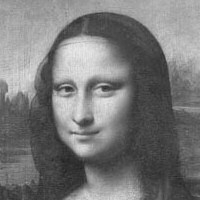

In [3]:
sharp = bc.Composition.load(IMAGE_PATH).grayscale()
sharp_image = render_grayscale(sharp)
sharp_image


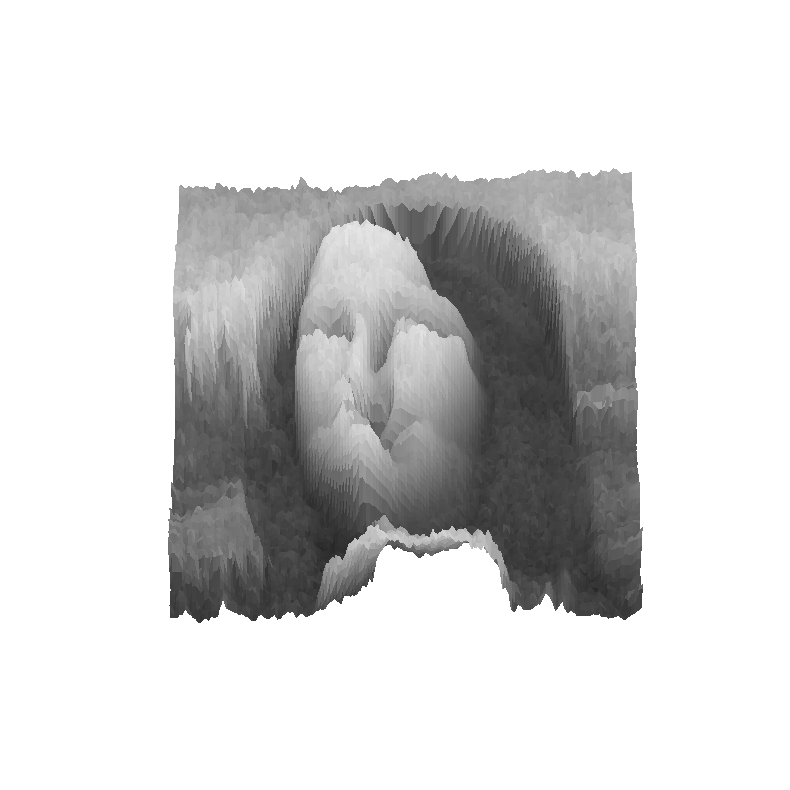

In [4]:
plot_heightmap(heightmap(sharp_image))

## Gaussian-blurred grayscale

The blur is applied to the composition in BrushCue, before the image is converted into a heightmap. The `crop` trims off the half-sigma border where the blur samples outside the original image bounds.


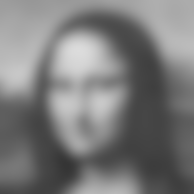

In [5]:
BLUR_SIGMA = 6

blur_source = bc.Composition.load(IMAGE_PATH)
bounds = blur_source.bounds()
crop_bounds = bc.Bounds2f.from_x_y_width_height(
    bounds.min_x() + BLUR_SIGMA / 2,
    bounds.min_y() + BLUR_SIGMA / 2,
    bounds.width() - BLUR_SIGMA,
    bounds.height() - BLUR_SIGMA,
)

blurred = blur_source.gaussian_blur(BLUR_SIGMA).crop(crop_bounds).grayscale()
blurred_image = render_grayscale(blurred)
blurred_image


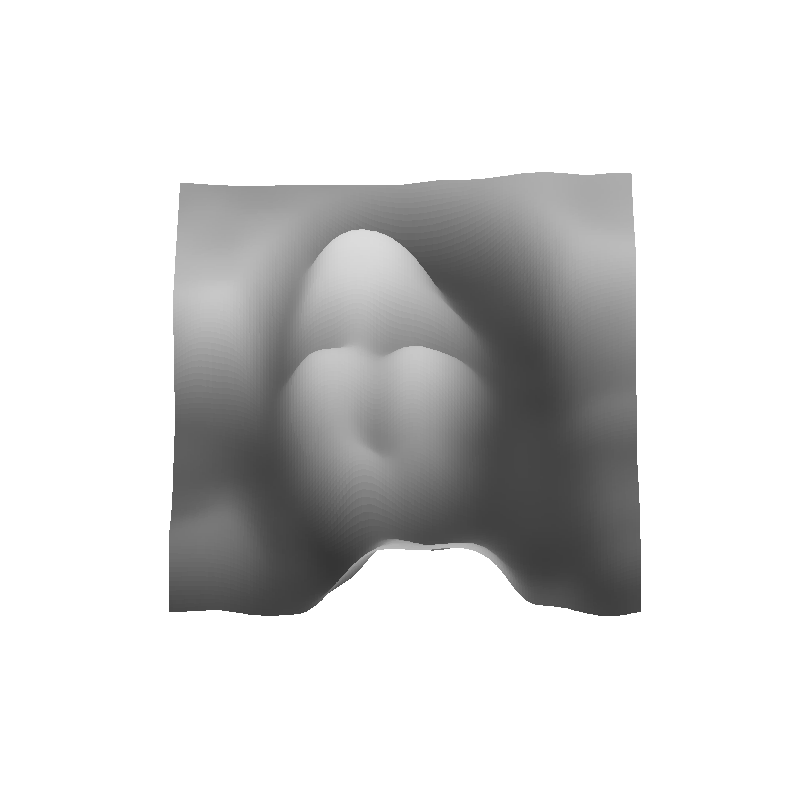

In [6]:
plot_heightmap(heightmap(blurred_image))

## High frequency (original minus blurred)

Subtracting the blurred (low-frequency) image from the original leaves just the high-frequency detail — the fast, small-scale changes the blur smoothed away. That difference is signed: pixels that got darker under the blur go negative, pixels that got brighter go positive, and untouched areas land at 0. Cropping the original to the same bounds as the blur keeps every pixel aligned before subtracting.

Rather than clamp those negative values away, the surface itself dips below the `z = 0` plane. Color stays grayscale: brightness alone encodes the sign, with black = most negative, mid-gray = 0, and white = most positive.


In [7]:
sharp_cropped_image = render_grayscale(blur_source.crop(crop_bounds).grayscale())
high_freq = heightmap(sharp_cropped_image) - heightmap(blurred_image)


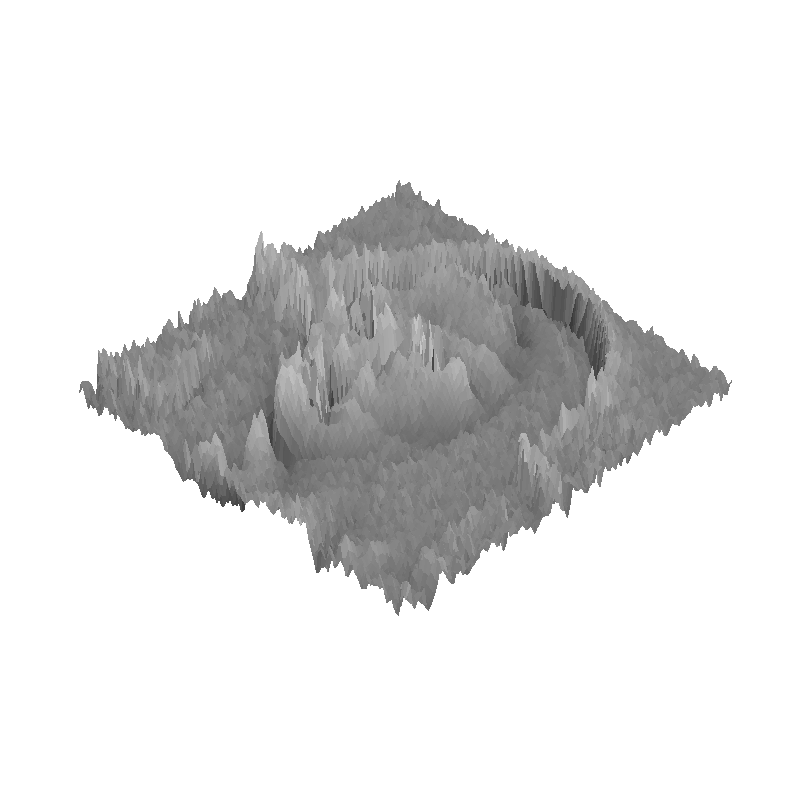

In [8]:
plot_diff_heightmap(high_freq)

## Export for the frequency chapter

Saves the raw grayscale images and the 3D models (sharp, blurred, and high-frequency, all viewed from the diagonal that reads best: `elev=40, azim=-45`) into the `frequency` chapter's asset folder in the graphics book.

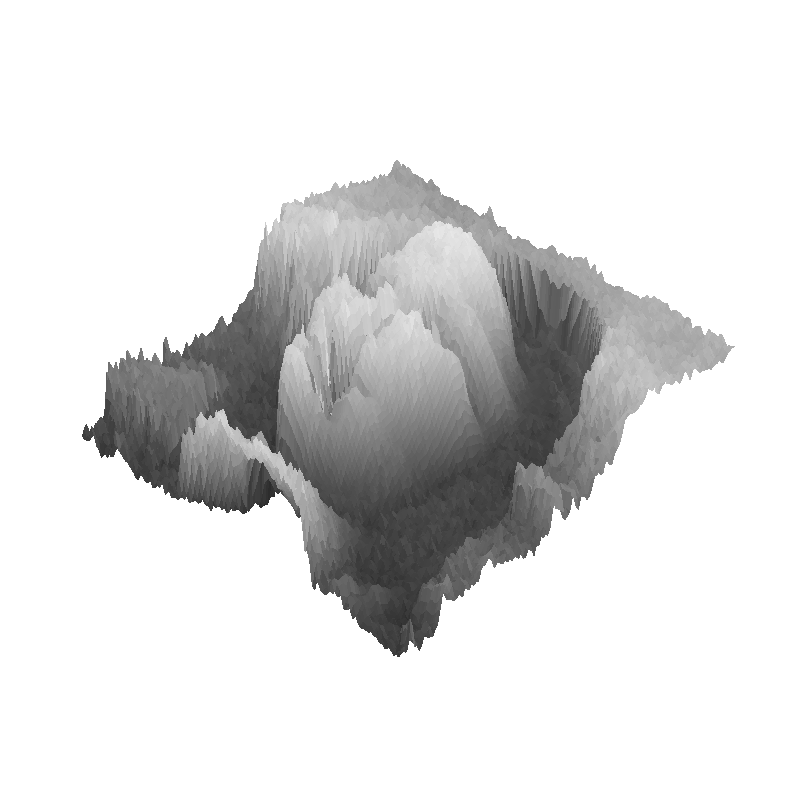

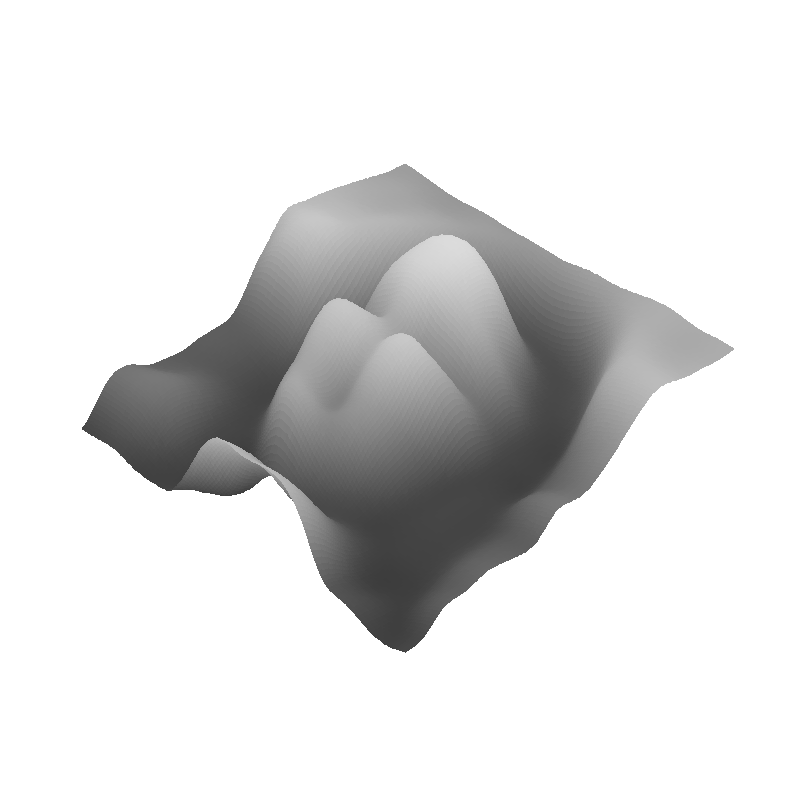

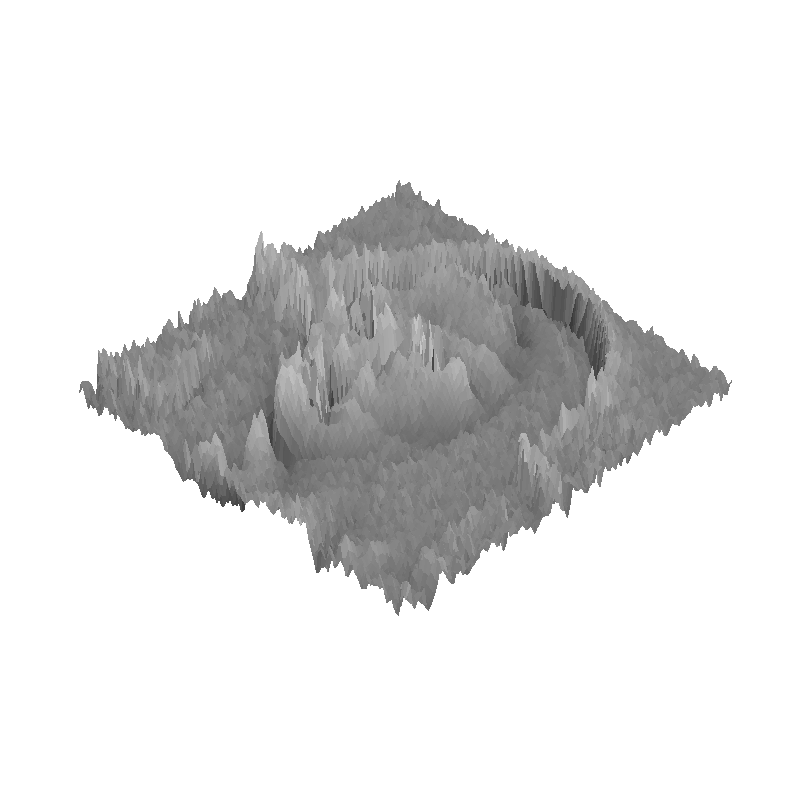

In [9]:
ASSETS_DIR = Path("../../../../../writing/graphics/chapters/frequency/assets").resolve()
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

sharp_image.save(ASSETS_DIR / "mona-lisa-grayscale.png")
blurred_image.save(ASSETS_DIR / "mona-lisa-grayscale-blurred.png")
plot_heightmap(
    heightmap(sharp_image),
    elev=40,
    azim=-45,
    save_path=ASSETS_DIR / "mona-lisa-3d-model.png",
)
plot_heightmap(
    heightmap(blurred_image),
    elev=40,
    azim=-45,
    save_path=ASSETS_DIR / "mona-lisa-3d-model-blurred.png",
)
plot_diff_heightmap(
    high_freq,
    save_path=ASSETS_DIR / "mona-lisa-3d-model-high-frequency.png",
)